# D2 Optical Pumping — Data Processing Pipeline

This notebook orchestrates the full processing chain for oscilloscope
CSV files recorded during the D2 optical-pumping experiment:

1. **Parse** filename metadata (RF frequency, category).
2. **Segment** the CH3 sweep into valid rising-edge cycles.
3. **Detect** absorption dips in CH2 and cluster them across cycles.
4. **Aggregate** with combined (Type A + B) uncertainty.
5. **Tag** each dip group (B0 / Rb-85 / Rb-87).
6. **Export** to `data/interim/D2.csv`.
7. **Visualise** overlaid cycles with tagged dips.

In [1]:
import sys, os, glob
import numpy as np
import pandas as pd

# Allow imports from the project root
sys.path.insert(0, os.path.abspath(".."))

from src.utils.file_parser import parse_metadata
from src.signal.segmentation import extract_valid_cycles
from src.signal.detection import detect_dips
from src.logic.tagger import assign_tags
from src.uncertainty.evaluation import get_combined_ufloat

In [2]:
# ---- Configuration ----
DATA_DIR = "../data/raw/D2_Optical_Pumping/0413/"
OUTPUT_PATH = "../data/interim/D2.csv"
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

## Pipeline Loop

Process every `.csv` in the raw data directory: parse, segment, detect,
aggregate with uncertainty, tag, and collect into a single results table.

In [3]:
import importlib
import src.utils.file_parser
import src.logic.tagger
import math

importlib.reload(src.utils.file_parser)
importlib.reload(src.logic.tagger)
from src.utils.file_parser import parse_metadata
from src.logic.tagger import assign_tags

all_results = []
# Store per-file data for the visualisation cell
vis_store = {}

csv_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))

for filepath in csv_files:
    filename = os.path.basename(filepath)
    print(f"\n{'=' * 60}")
    print(f"Processing: {filename}")

    # 1. Parse metadata --------------------------------------------------
    meta = parse_metadata(filename)
    if meta["category"] is None:
        print(f"  Skipping unrecognised file: {filename}")
        continue
    print(f"  Category {meta['category']}  |  RF freq = {meta['rf_freq']} Hz")

    # 2. Load CSV (11 header rows -> row 12 = column names) --------------
    df_raw = pd.read_csv(filepath, skiprows=11)
    df_raw.columns = ["Second", "CH2", "CH3"]
    time_data = df_raw["Second"].values
    ch2_data = df_raw["CH2"].values
    ch3_data = df_raw["CH3"].values

    # 3. Segment CH3 sweep -----------------------------------------------
    ch3_norm, valid_segments = extract_valid_cycles(time_data, ch3_data)
    print(f"  Valid cycles: {len(valid_segments)}")
    if len(valid_segments) == 0:
        print("  -> No valid cycles found, skipping.")
        continue

    # 4. Detect dips -----------------------------------------------------
    dips_df = detect_dips(time_data, ch2_data, ch3_norm, valid_segments)
    n_groups = dips_df["Group"].nunique() if len(dips_df) else 0
    print(f"  Dips detected: {len(dips_df)}  in {n_groups} group(s)")
    if len(dips_df) == 0:
        print("  -> No dips detected, skipping.")
        continue

    # 5. Aggregate with uncertainty --------------------------------------
    agg_rows = []
    for group_id, grp in dips_df.groupby("Group"):
        time_u = get_combined_ufloat(grp["Relative_Time"].tolist(), resolution=0.01)
        ch3_u = get_combined_ufloat(grp["CH3_Voltage"].tolist(), resolution=0.01)
        agg_rows.append(
            {
                "Relative_Time": time_u.nominal_value,
                "Time_Uncertainty": time_u.std_dev,
                "CH3_Voltage": ch3_u.nominal_value,
                "CH3_Uncertainty": ch3_u.std_dev,
                "CH2_Depth": grp["CH2_Depth"].mean(),
            }
        )

    agg_df = pd.DataFrame(agg_rows).sort_values("Relative_Time").reset_index(drop=True)

    # 6. Tag dips --------------------------------------------------------
    tagged_df = assign_tags(agg_df, meta["category"])

    # 客製化邏輯：如果 freq >= 300k
    rf_freq = meta.get("rf_freq")
    if rf_freq is not None and rf_freq >= 300000:
        tagged_df = tagged_df.sort_values("Relative_Time").reset_index(drop=True)
        if rf_freq == 1000000:
            # 1000kHz 時，兩個獨立檔案
            if "85" in filename:
                tagged_df.loc[0, "tag"] = "Rb-85"
                if len(tagged_df) > 1:
                    tagged_df.loc[1:, "tag"] = "invalid"
            elif "87" in filename:
                tagged_df.loc[0, "tag"] = "Rb-87"
                if len(tagged_df) > 1:
                    tagged_df.loc[1:, "tag"] = "invalid"
        else:
            # 300k ~ 900k：固定有兩個 dip，依照順序第一個是 Rb-85，第二個是 Rb-87
            if len(tagged_df) >= 1:
                tagged_df.loc[0, "tag"] = "Rb-85"
            if len(tagged_df) >= 2:
                tagged_df.loc[1, "tag"] = "Rb-87"
            if len(tagged_df) > 2:
                tagged_df.loc[2:, "tag"] = "invalid"

    print(f"  Tags: {tagged_df['tag'].tolist()}")

    # 7. Collect results -------------------------------------------------

    # 處理 MAIN files 的 current & uncertainty (電阻 0.5 歐姆，所以 V_mV * 2 = I_mA)
    main_current = meta.get("main_field_current")
    main_current_u = None

    if "MAIN" in filename.upper():
        v_mv = None
        if "200" in filename:
            v_mv = 7.6
        elif "300" in filename:
            v_mv = 20.9
        elif "400" in filename:
            v_mv = 32.9
        elif "500" in filename:
            v_mv = 44.9
        elif "1000" in filename:
            if "85" in filename:
                v_mv = 65.1
            elif "87" in filename:
                v_mv = 108.0

        if v_mv is not None:
            # V / 0.5 = V * 2
            # 假設您需要的單位是 A (如果是 mA 就不需要除 1000，這裡除以 1000 轉換為 A。如需修改可自行拿掉 /1000)
            main_current = (v_mv * 2) / 1000.0
            main_current_u = ((0.1 / math.sqrt(12)) * 2) / 1000.0

    for _, row in tagged_df.iterrows():
        all_results.append(
            {
                "RF freq.": meta["rf_freq"],
                "main field current": main_current,
                "main field current uncertainty": main_current_u,
                "time position": row["Relative_Time"],
                "time uncertainty": row["Time_Uncertainty"],
                "CH3 current": row["CH3_Voltage"],
                "CH3 current uncertainty": row["CH3_Uncertainty"],
                "dip depth": row["CH2_Depth"],
                "tag": row["tag"],
            }
        )

    # Save data for visualisation later
    vis_store[filename] = {
        "time": time_data,
        "ch2": ch2_data,
        "ch3_norm": ch3_norm,
        "segments": valid_segments,
        "dips_df": dips_df,
        "tagged": tagged_df,
        "meta": meta,
    }

print(f"\n{'=' * 60}")
print(f"Total result rows: {len(all_results)}")


Processing: 1000KHZ_MAIN_85.csv
  Category 3  |  RF freq = 1000000 Hz
  Valid cycles: 6
  Dips detected: 6  in 1 group(s)
  Tags: ['Rb-85']

Processing: 1000KHZ_MAIN_87.csv
  Category 3  |  RF freq = 1000000 Hz
  Valid cycles: 6
  Dips detected: 6  in 1 group(s)
  Tags: ['Rb-87']

Processing: 110KHZ_RF.csv
  Category 2  |  RF freq = 110000 Hz
  Valid cycles: 5
  Dips detected: 20  in 4 group(s)
  Tags: ['invalid', 'B0', 'Rb-85', 'Rb-87']

Processing: 130KHZ_RF.csv
  Category 2  |  RF freq = 130000 Hz
  Valid cycles: 5
  Dips detected: 20  in 4 group(s)
  Tags: ['invalid', 'B0', 'Rb-85', 'Rb-87']

Processing: 150KHZ_RF.csv
  Category 2  |  RF freq = 150000 Hz
  Valid cycles: 5
  Dips detected: 16  in 4 group(s)
  Tags: ['invalid', 'B0', 'Rb-85', 'Rb-87']

Processing: 170KHZ_RF.csv
  Category 2  |  RF freq = 170000 Hz
  Valid cycles: 6
  Dips detected: 12  in 2 group(s)
  Tags: ['B0', 'Rb-85']

Processing: 200KHZ_MAIN.csv
  Category 2  |  RF freq = 200000 Hz
  Valid cycles: 6
  Dips det

## Export

In [4]:
results_df = pd.DataFrame(all_results)
results_df.to_csv(OUTPUT_PATH, index=False)
print(f"Exported {len(results_df)} rows -> {OUTPUT_PATH}")
results_df

Exported 38 rows -> ../data/interim/D2.csv


,RF freq.,main field current,main field current uncertainty,time position,time uncertainty,CH3 current,CH3 current uncertainty,dip depth,tag
0,1000000,0.1302,0.000058,0.979258,0.004385,0.842767,0.003200,0.420140,Rb-85
1,1000000,0.2160,0.000058,0.935360,0.003269,0.798008,0.003086,0.324623,Rb-87
2,110000,NaN,NaN,0.077234,0.003309,0.072840,0.003166,0.526778,invalid
3,110000,NaN,NaN,0.386524,0.003118,0.334282,0.003297,0.934794,B0
4,110000,NaN,NaN,0.691362,0.003355,0.595725,0.003297,0.473453,Rb-85
5,110000,NaN,NaN,0.844803,0.003341,0.725796,0.003297,0.604367,Rb-87
6,130000,NaN,NaN,0.021069,0.003287,0.024713,0.003166,0.395218,invalid
7,130000,NaN,NaN,0.385108,0.003318,0.334282,0.003886,0.930978,B0
8,130000,NaN,NaN,0.746930,0.003029,0.639949,0.003297,0.461126,Rb-85
9,130000,NaN,NaN,0.927942,0.003023,0.798635,0.003166,0.579848,Rb-87


## Overlaid Cycle Plots

For each processed file the plot shows:
- **Top panel** — normalised CH3 ramp for every valid cycle (relative time).
- **Bottom panel** — CH2 photodetector traces with tagged dip positions
  colour-coded by label.

In [5]:
import matplotlib.pyplot as plt
from src.visualization.plot_settings import apply_plot_style

TAG_COLORS = {
    "B0": "#4472C4",
    "Rb-85": "#E06932",
    "Rb-87": "#4EAA72",
    "invalid": "#AAAAAA",
    "unknown": "#C4499E",
}


def plot_overlaid_cycles(name, store):
    """Two-panel overlay plot for a single file."""
    apply_plot_style("base")

    t_all = store["time"]
    ch2_all = store["ch2"]
    ch3_norm = store["ch3_norm"]
    segments = store["segments"]
    tagged = store["tagged"]
    meta = store["meta"]

    fig, (ax_ch3, ax_ch2) = plt.subplots(
        2,
        1,
        figsize=(8, 6),
        sharex=True,
        constrained_layout=True,
    )
    fig.suptitle(
        f"{name}   (Cat {meta['category']},  RF = {meta['rf_freq']} Hz)",
        fontsize=13,
    )

    for cyc_idx, (s, e) in enumerate(segments):
        rel_t = t_all[s : e + 1] - t_all[s]
        # Top: CH3 normalised ramp
        ax_ch3.plot(
            rel_t,
            ch3_norm[s : e + 1],
            alpha=0.5,
            lw=0.8,
            label=f"Cycle {cyc_idx}" if cyc_idx < 6 else None,
        )
        # Bottom: CH2 traces
        ax_ch2.plot(rel_t, ch2_all[s : e + 1], alpha=0.4, lw=0.6, color="grey")

    # Overlay tagged dip scatter on CH2 panel
    for _, row in tagged.iterrows():
        colour = TAG_COLORS.get(row["tag"], "black")
        ax_ch2.axvline(row["Relative_Time"], color=colour, ls="--", lw=0.8, alpha=0.6)
        ax_ch2.scatter(
            row["Relative_Time"],
            -row["CH2_Depth"],
            color=colour,
            s=60,
            zorder=5,
            edgecolors="k",
            linewidths=0.5,
            label=row["tag"],
        )

    ax_ch3.set_ylabel("CH3 norm (V)")
    ax_ch2.set_ylabel("CH2 (V)")
    ax_ch2.set_xlabel("Relative time (s)")

    # De-duplicate legend labels
    handles, labels = ax_ch2.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax_ch2.legend(by_label.values(), by_label.keys(), loc="lower right")

    if len(segments) <= 6:
        ax_ch3.legend(loc="lower right", fontsize=9)

    plt.show()

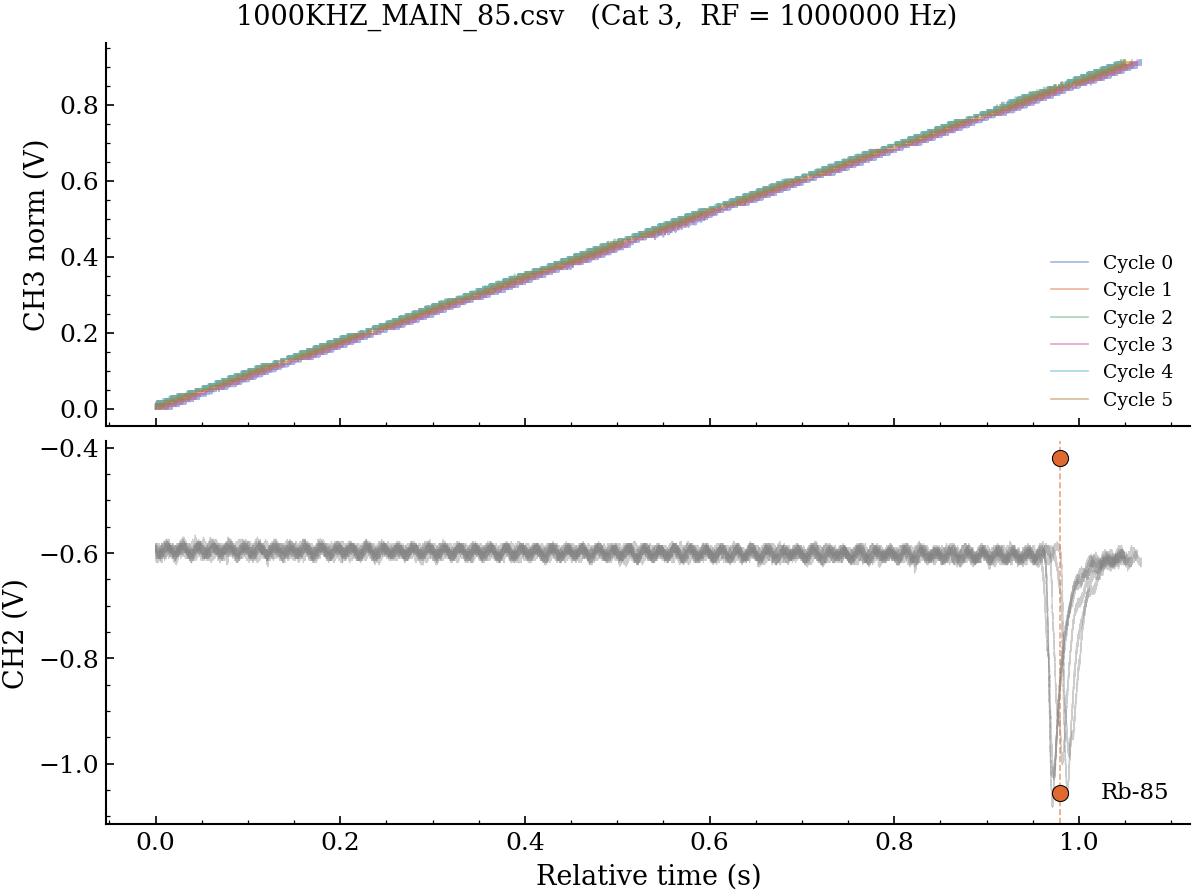

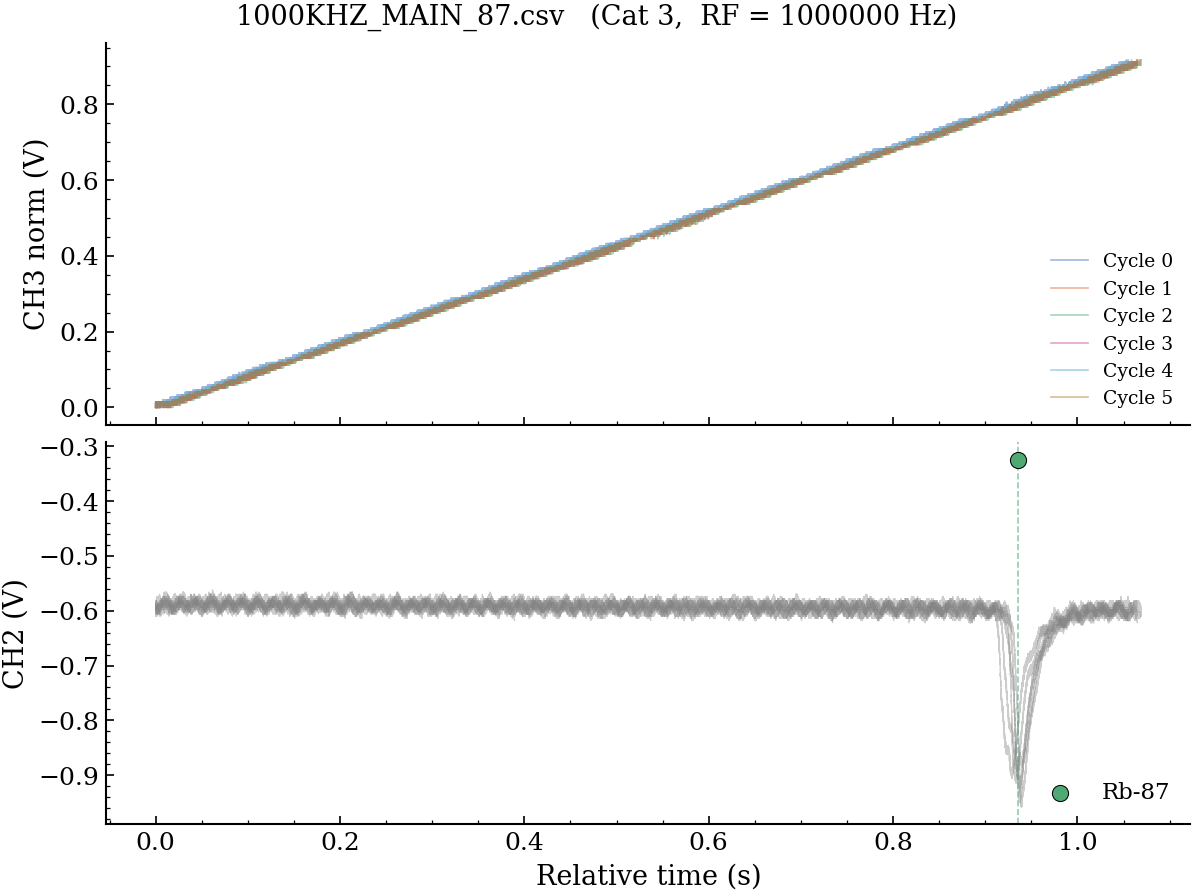

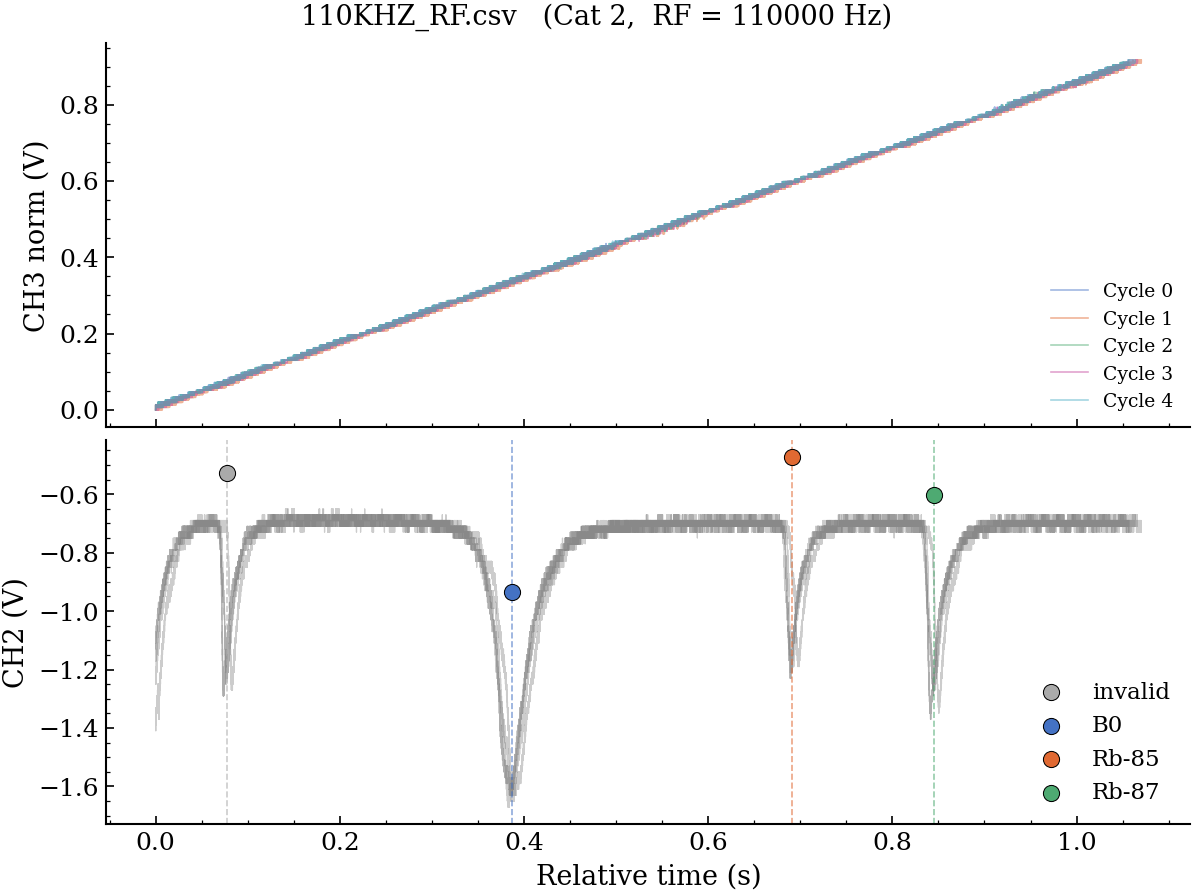

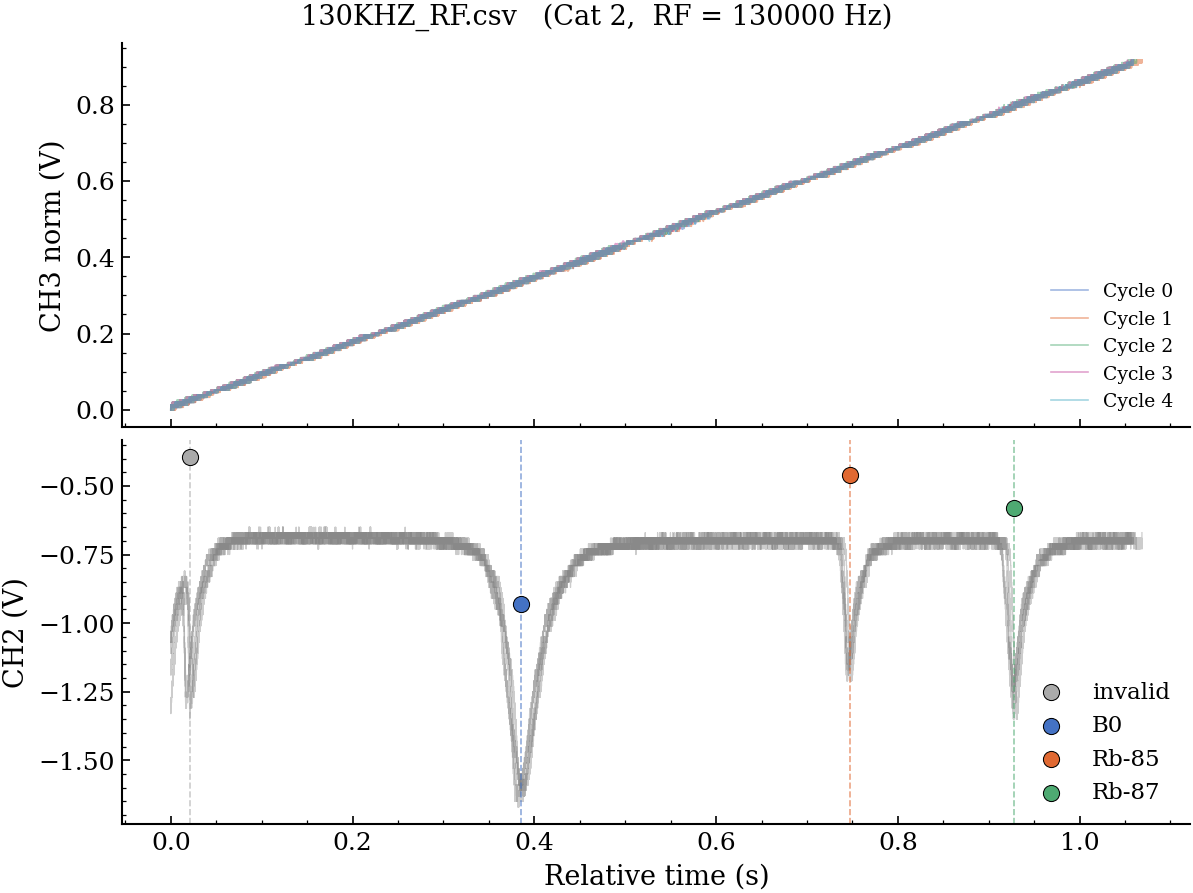

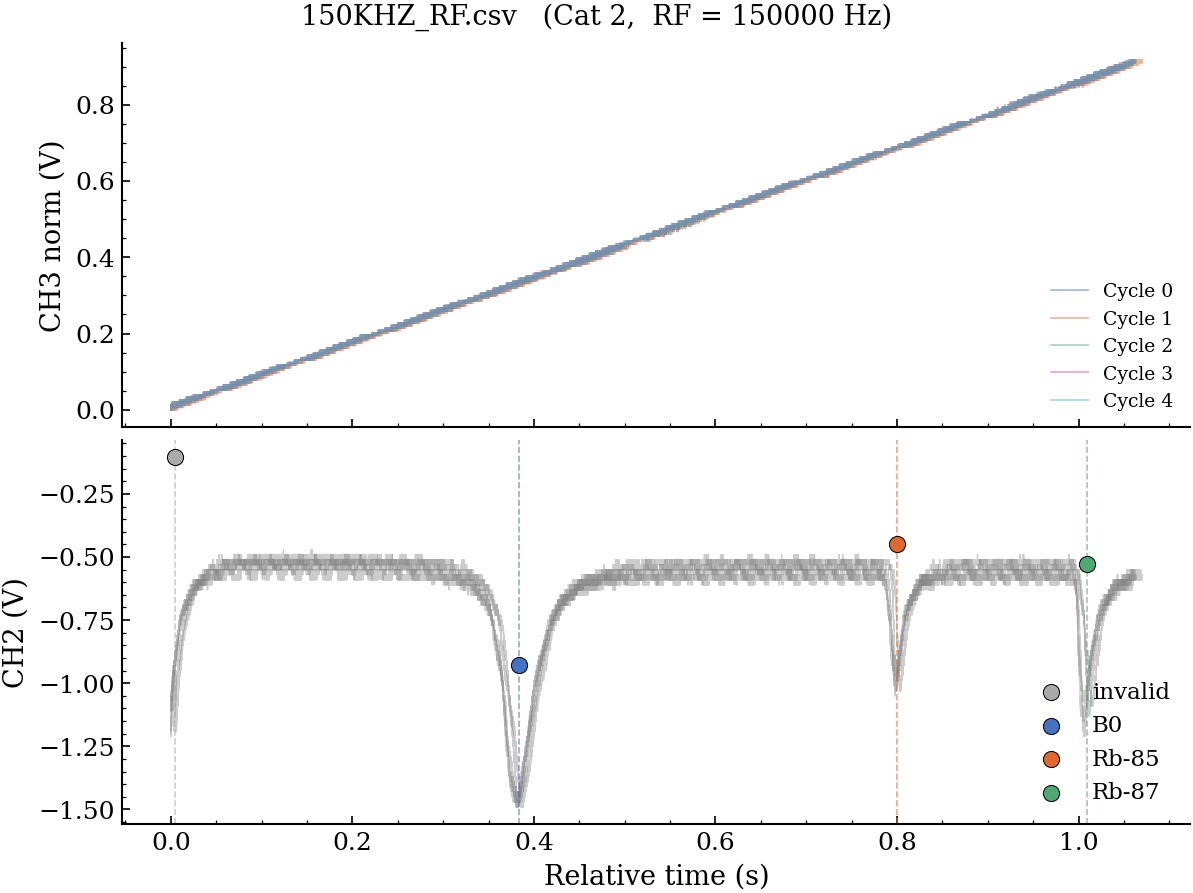

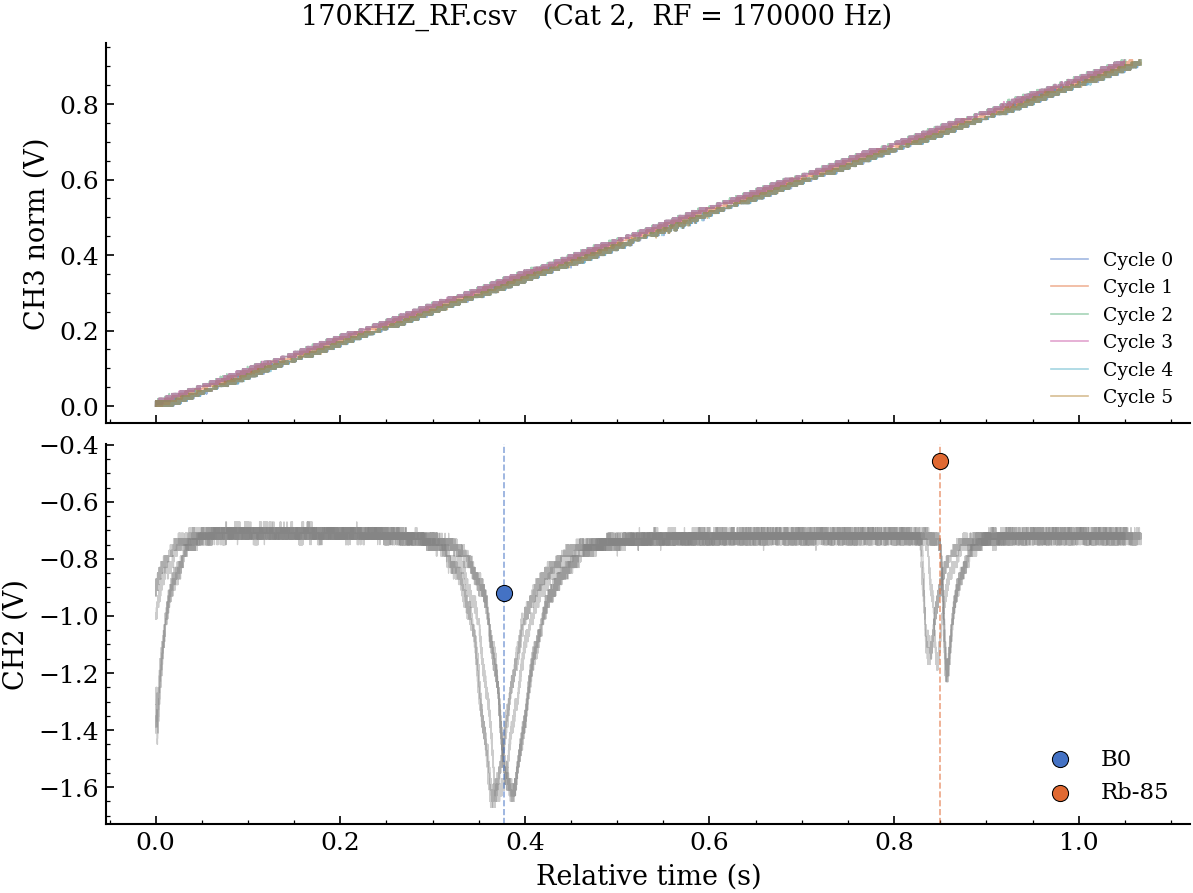

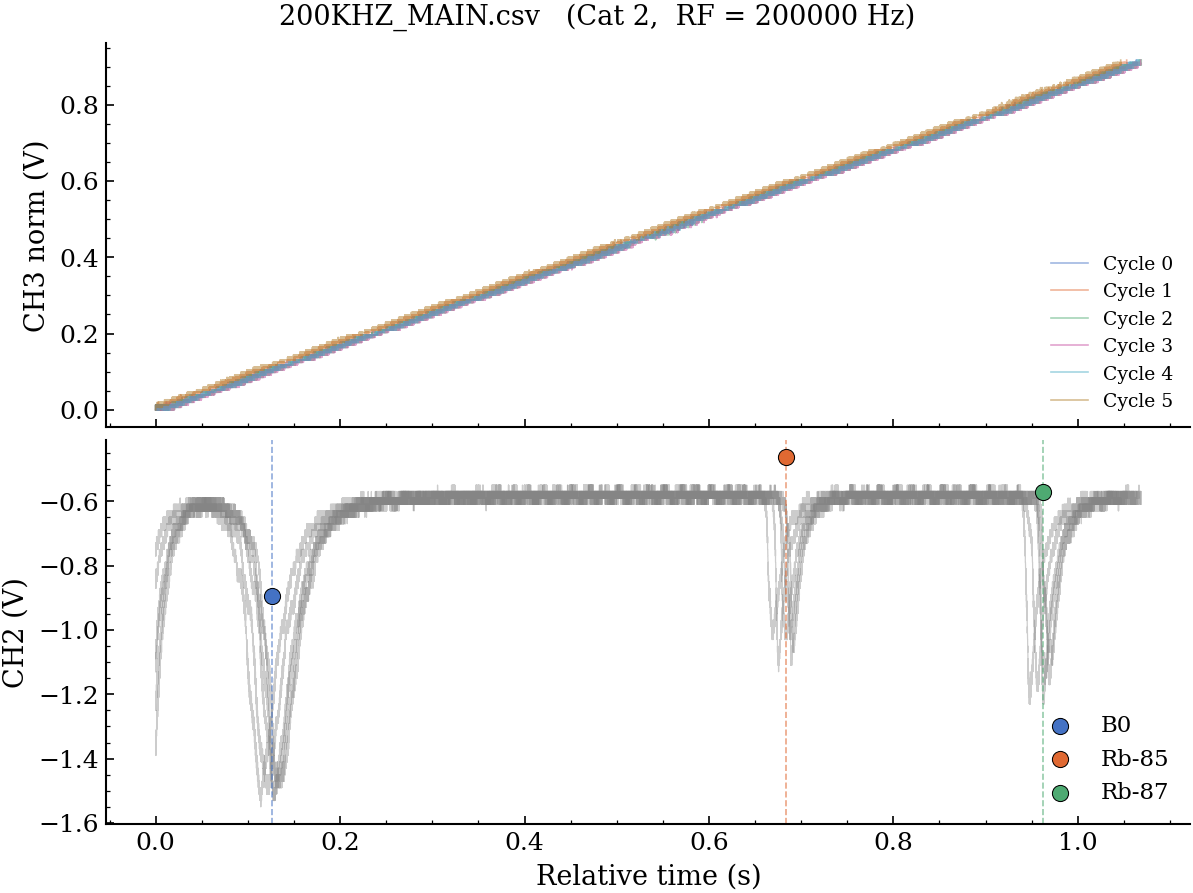

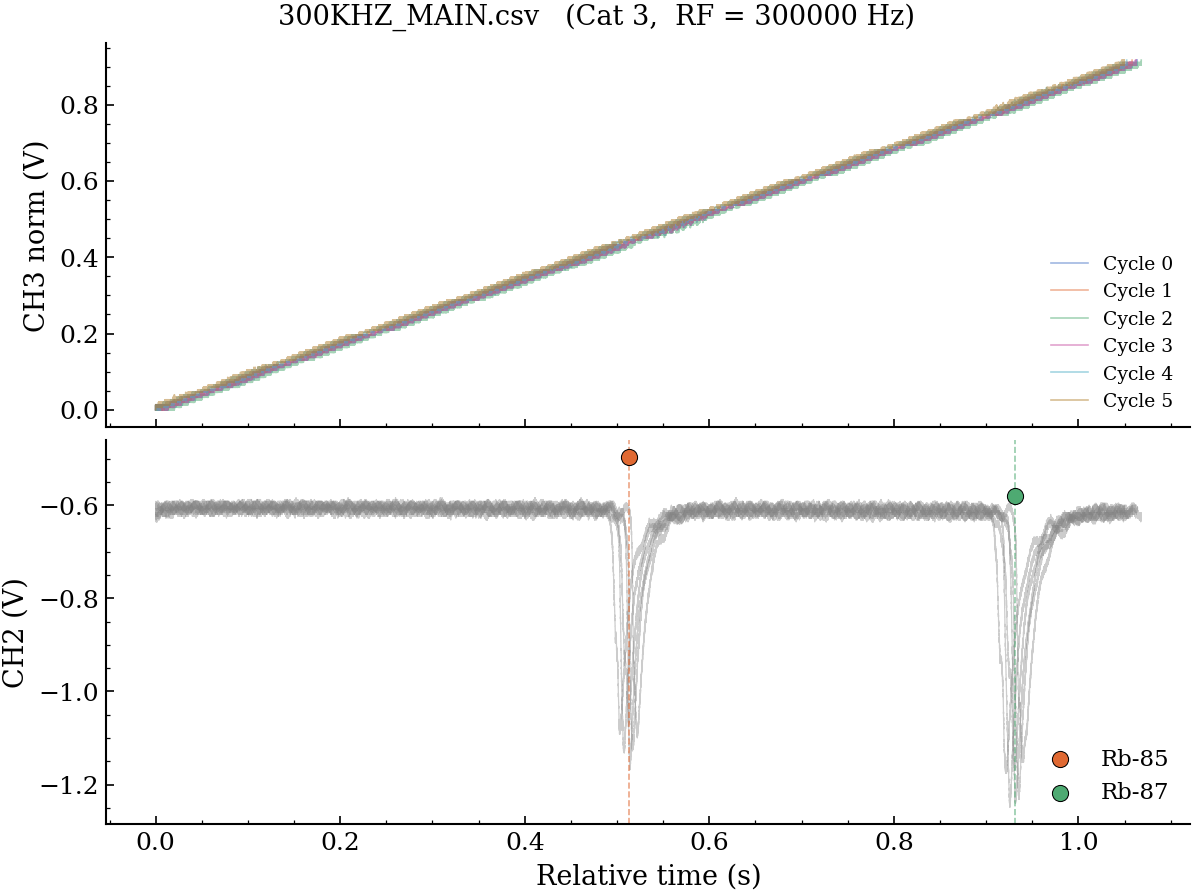

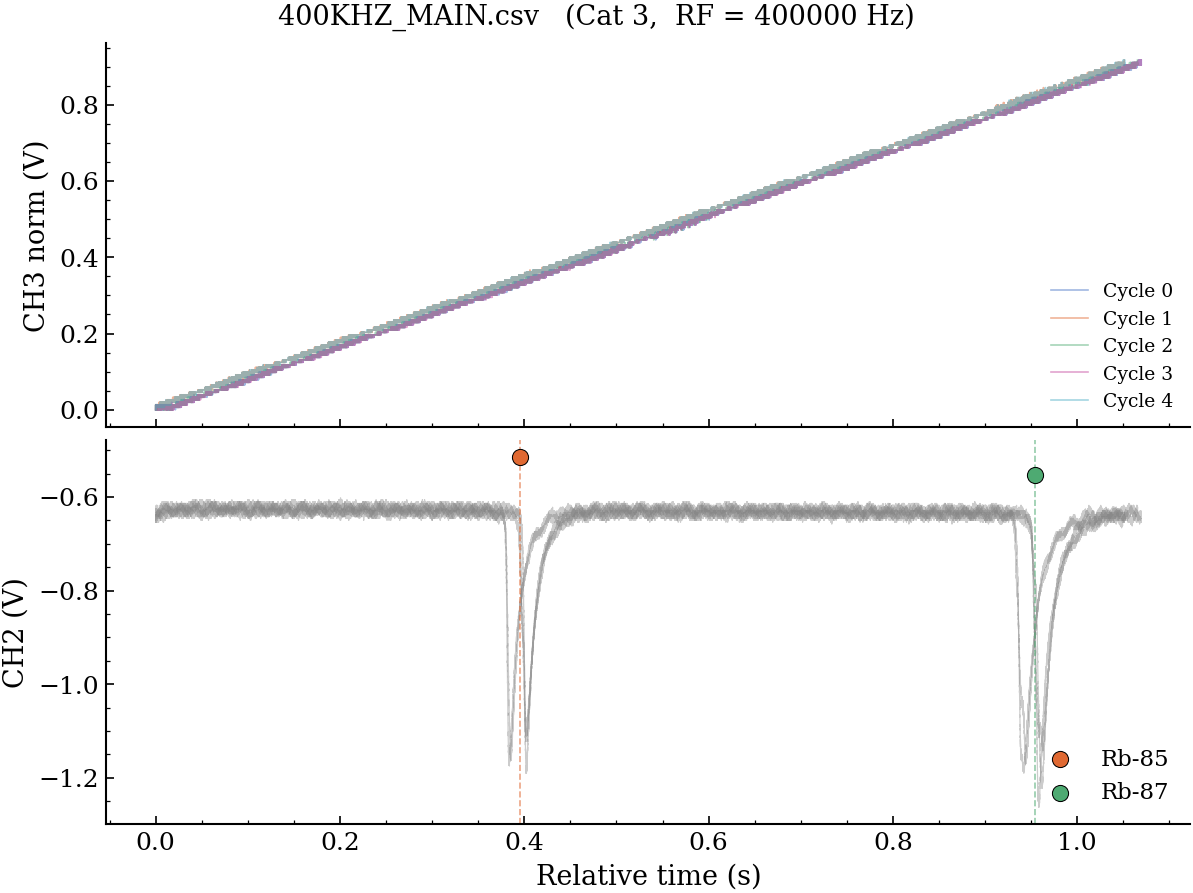

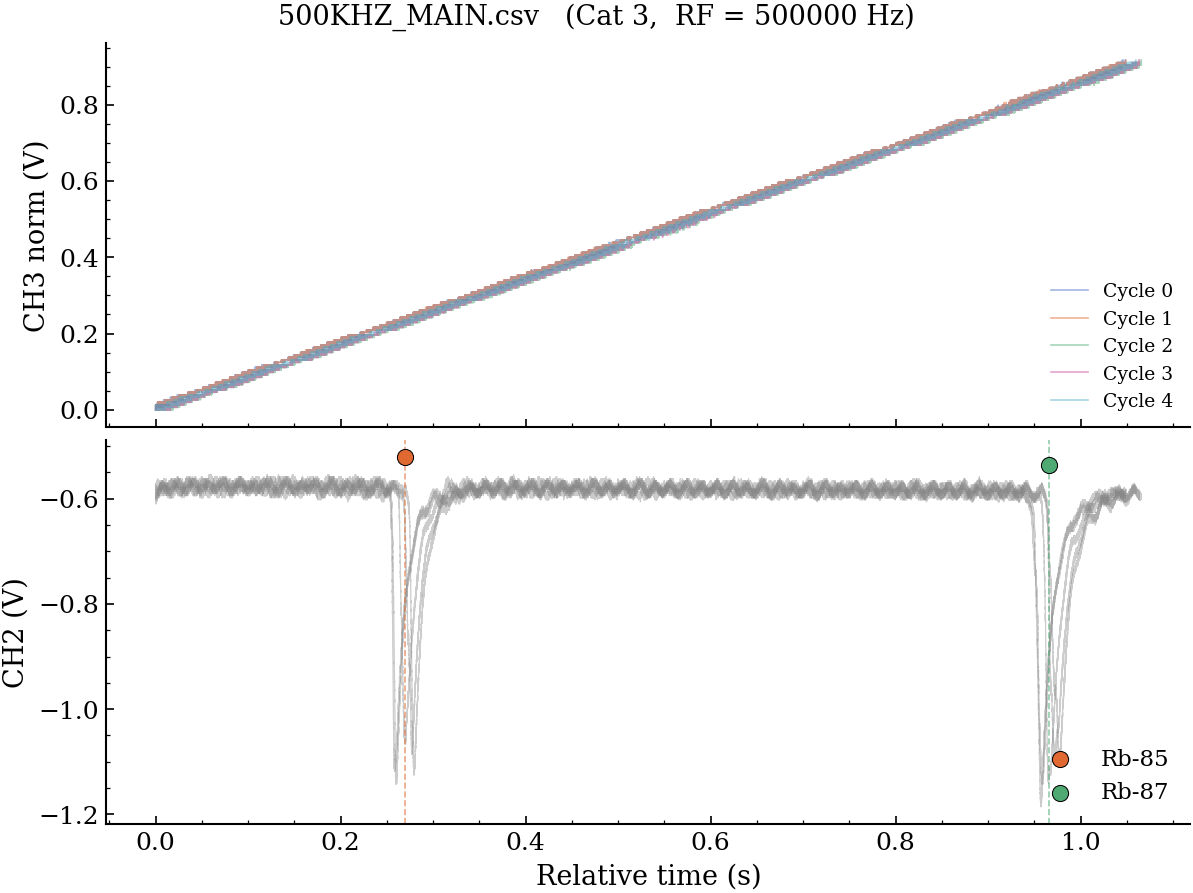

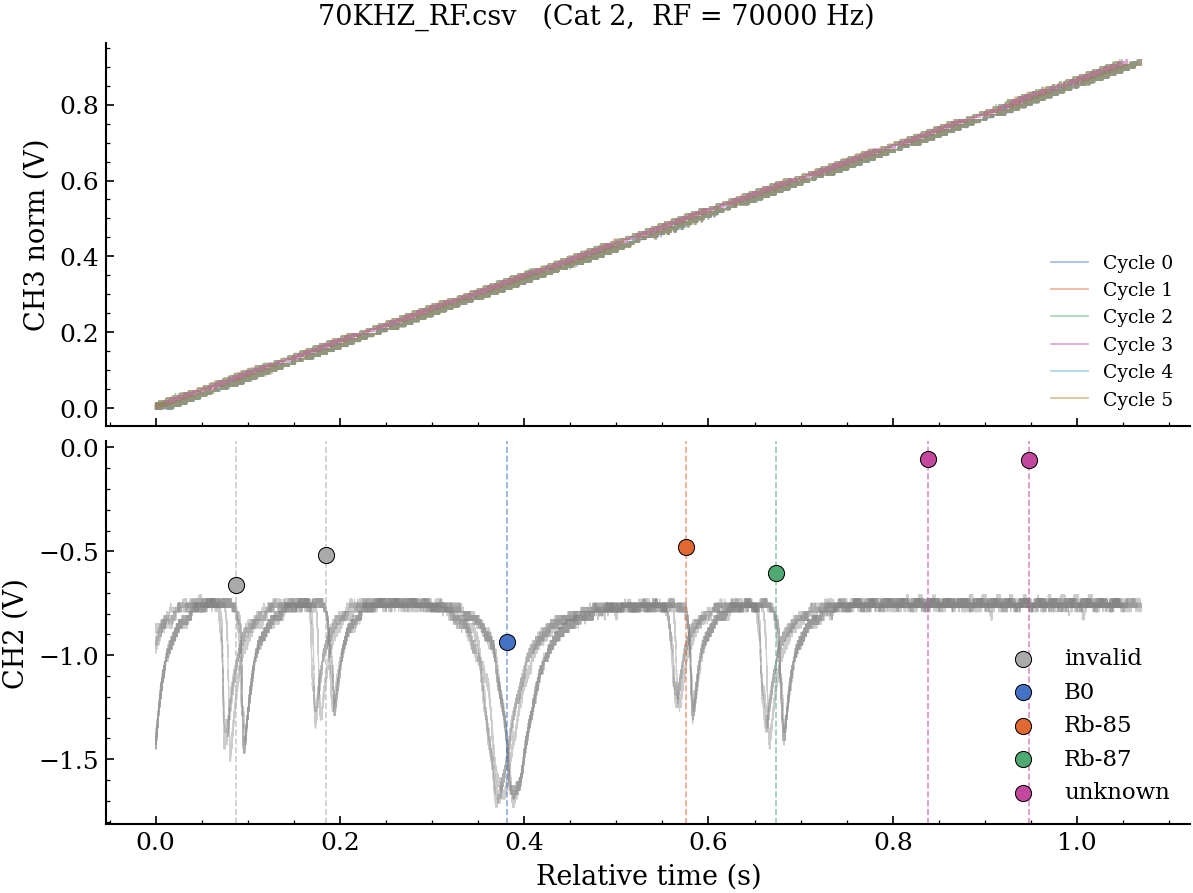

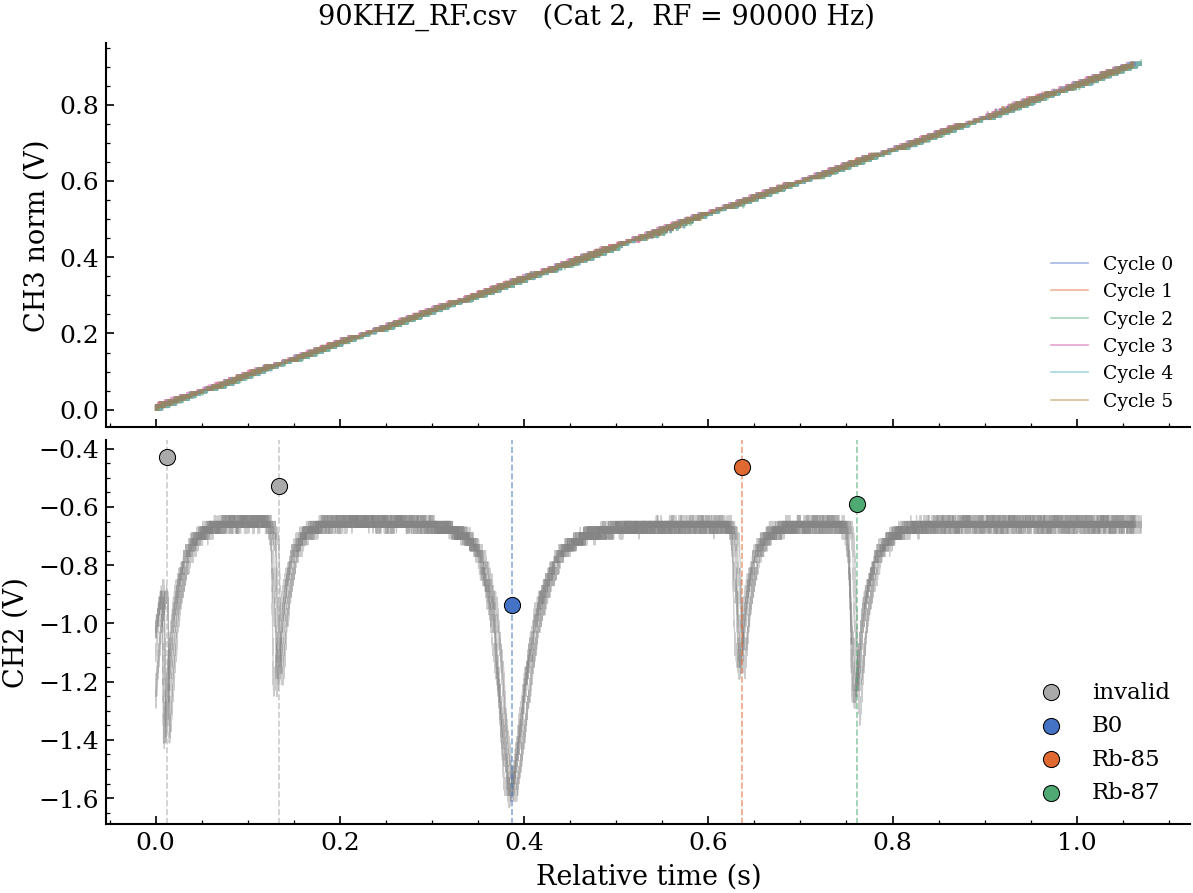

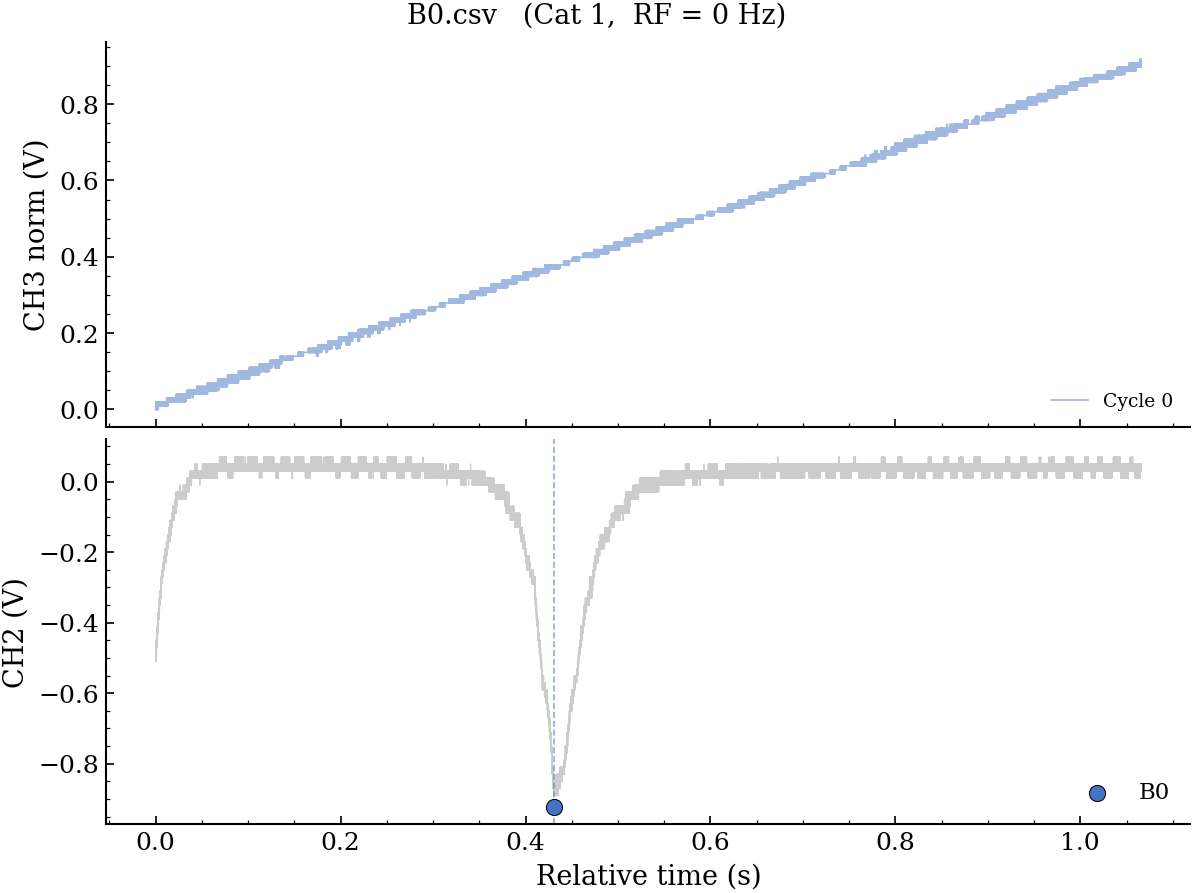

In [6]:
for name in sorted(vis_store):
    plot_overlaid_cycles(name, vis_store[name])